# 3 домашка по биоинформатике. 3 задание

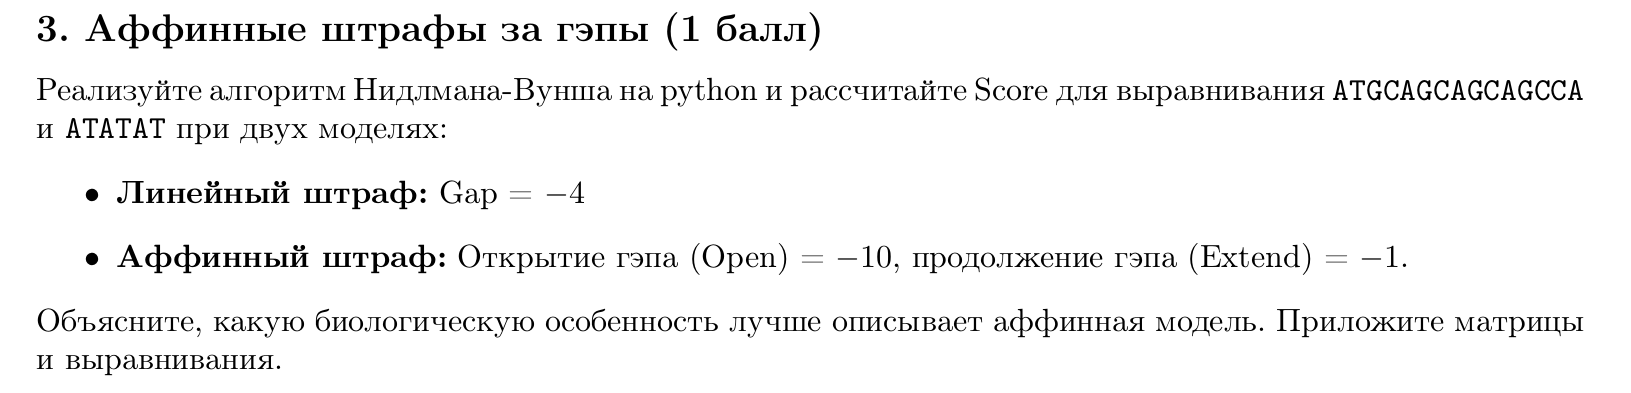

In [44]:
import pandas as pd

def print_matrix_pandas(matrix):
    """Вывод матрицы с помощью pandas,
    так как без него матрицы печатаются криво из-за двузначных скоров :("""
    df = pd.DataFrame(matrix)
    if s2:
        df.index = [''] + list(s2)
    if s1:
        df.columns = [''] + list(s1)

    print(df)

In [1]:
s1 = 'ATGCAGCAGCAGCCA'
s2 = 'ATATAT'

## Линейный штраф

##

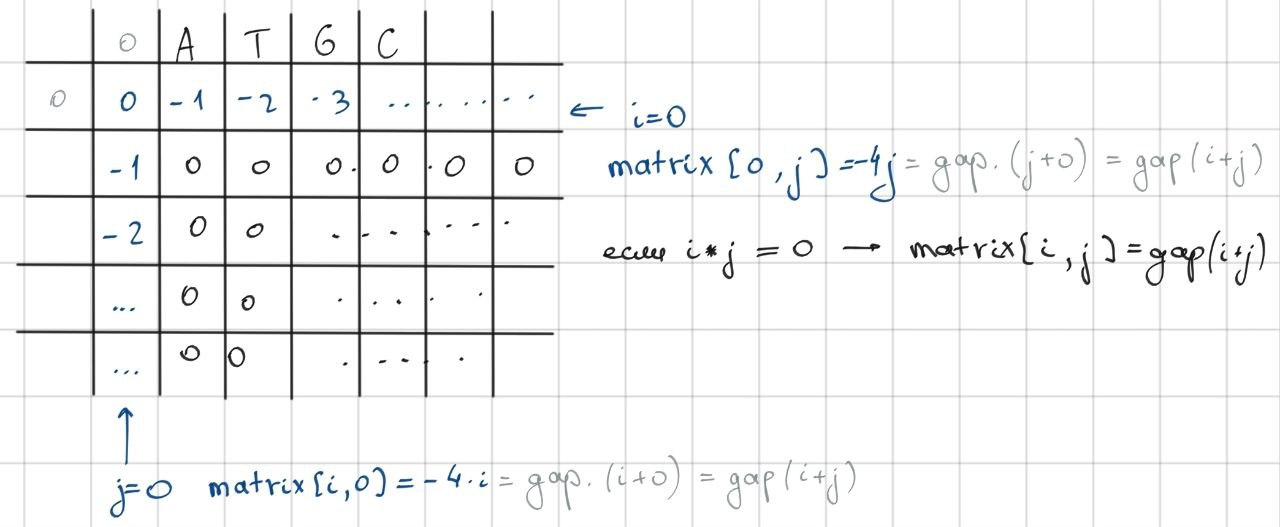

In [46]:
gap = -4
mismatch =-1
match = 1
matrix = [[gap*(i+j) if i*j==0 else 0 for i in range(len(s1)+1)] for j in range(len(s2)+1)]
matrix

[[0, -4, -8, -12, -16, -20, -24, -28, -32, -36, -40, -44, -48, -52, -56, -60],
 [-4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 [-8, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 [-12, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 [-16, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 [-20, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 [-24, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]

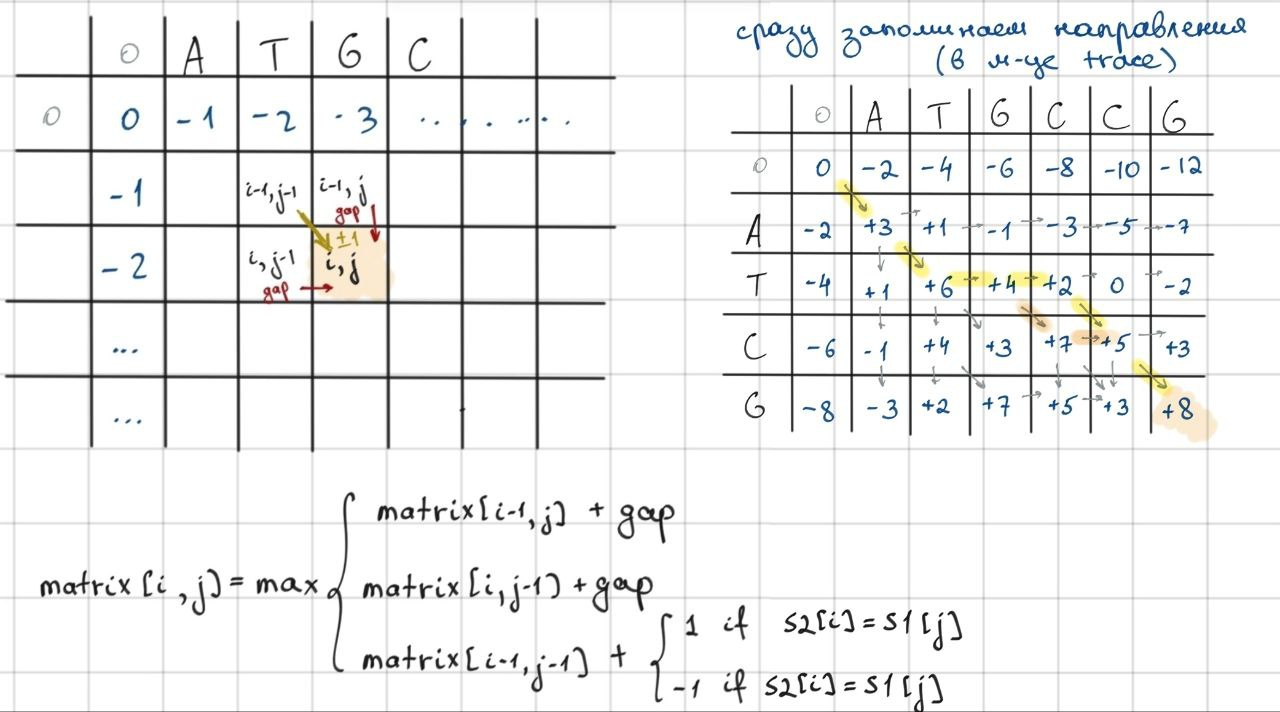

In [47]:
trace = [["вверх" if i>0 and j==0 else "влево" if j>0 and i==0 else "" for j in range(len(s1)+1)] for i in range(len(s2)+1)]

for i in range(1, len(s2)+1):
    for j in range(1, len(s1)+1):
        diag = matrix[i-1][j-1] + (match if s1[j-1]==s2[i-1] else mismatch)
        up = matrix[i-1][j] + gap
        left = matrix[i][j-1] + gap

        best = max(diag, up, left)
        matrix[i][j] = best

        if best == diag:
            trace[i][j] = "вправо"
        elif best == up:
            trace[i][j] = "вверх"
        else:
            trace[i][j] = "влево"

In [48]:
i = len(s2)
j = len(s1)
al1 = ""
al2 = ""

while i > 0 or j > 0:
    if trace[i][j] == "вправо":
        al1 = s1[j-1] + al1
        al2 = s2[i-1] + al2
        i -= 1
        j -= 1

    elif trace[i][j] == "влево":
        al1 = s1[j-1] + al1
        al2 = "-" + al2
        j -= 1

    else:
        al1 = "-" + al1
        al2 = s2[i-1] + al2
        i -= 1

In [49]:
print('Выравнивание:')
print(al1)
print(al2)

Выравнивание:
ATGCAGCAGCAGCCA
AT-----A-TA---T


In [50]:
print("Score:", matrix[len(s2)][len(s1)])
print('Матрица:')
print_matrix_pandas(matrix)

Score: -34
Матрица:
        A   T   G   C   A   G   C   A   G   C   A   G   C   C   A
    0  -4  -8 -12 -16 -20 -24 -28 -32 -36 -40 -44 -48 -52 -56 -60
A  -4   1  -3  -7 -11 -15 -19 -23 -27 -31 -35 -39 -43 -47 -51 -55
T  -8  -3   2  -2  -6 -10 -14 -18 -22 -26 -30 -34 -38 -42 -46 -50
A -12  -7  -2   1  -3  -5  -9 -13 -17 -21 -25 -29 -33 -37 -41 -45
T -16 -11  -6  -3   0  -4  -6 -10 -14 -18 -22 -26 -30 -34 -38 -42
A -20 -15 -10  -7  -4   1  -3  -7  -9 -13 -17 -21 -25 -29 -33 -37
T -24 -19 -14 -11  -8  -3   0  -4  -8 -10 -14 -18 -22 -26 -30 -34


## Афинный штраф

In [19]:
gap_open = -10
gap_extend = -1

matrix = [[(gap_open + gap_extend*(i+j-1)) if i*j==0 else 0 for j in range(len(s1)+1)] for i in range(len(s2)+1)]
matrix[0][0] = 0

X = [[(gap_open + gap_extend*(i-1)) if j==0 and i>0 else float("-inf") if i==0 and j>0 else 0 for j in range(len(s1)+1)] for i in range(len(s2)+1)]

Y = [[(gap_open + gap_extend*(j-1)) if i==0 and j>0 else float("-inf") if j==0 and i>0 else 0 for j in range(len(s1)+1)] for i in range(len(s2)+1)]

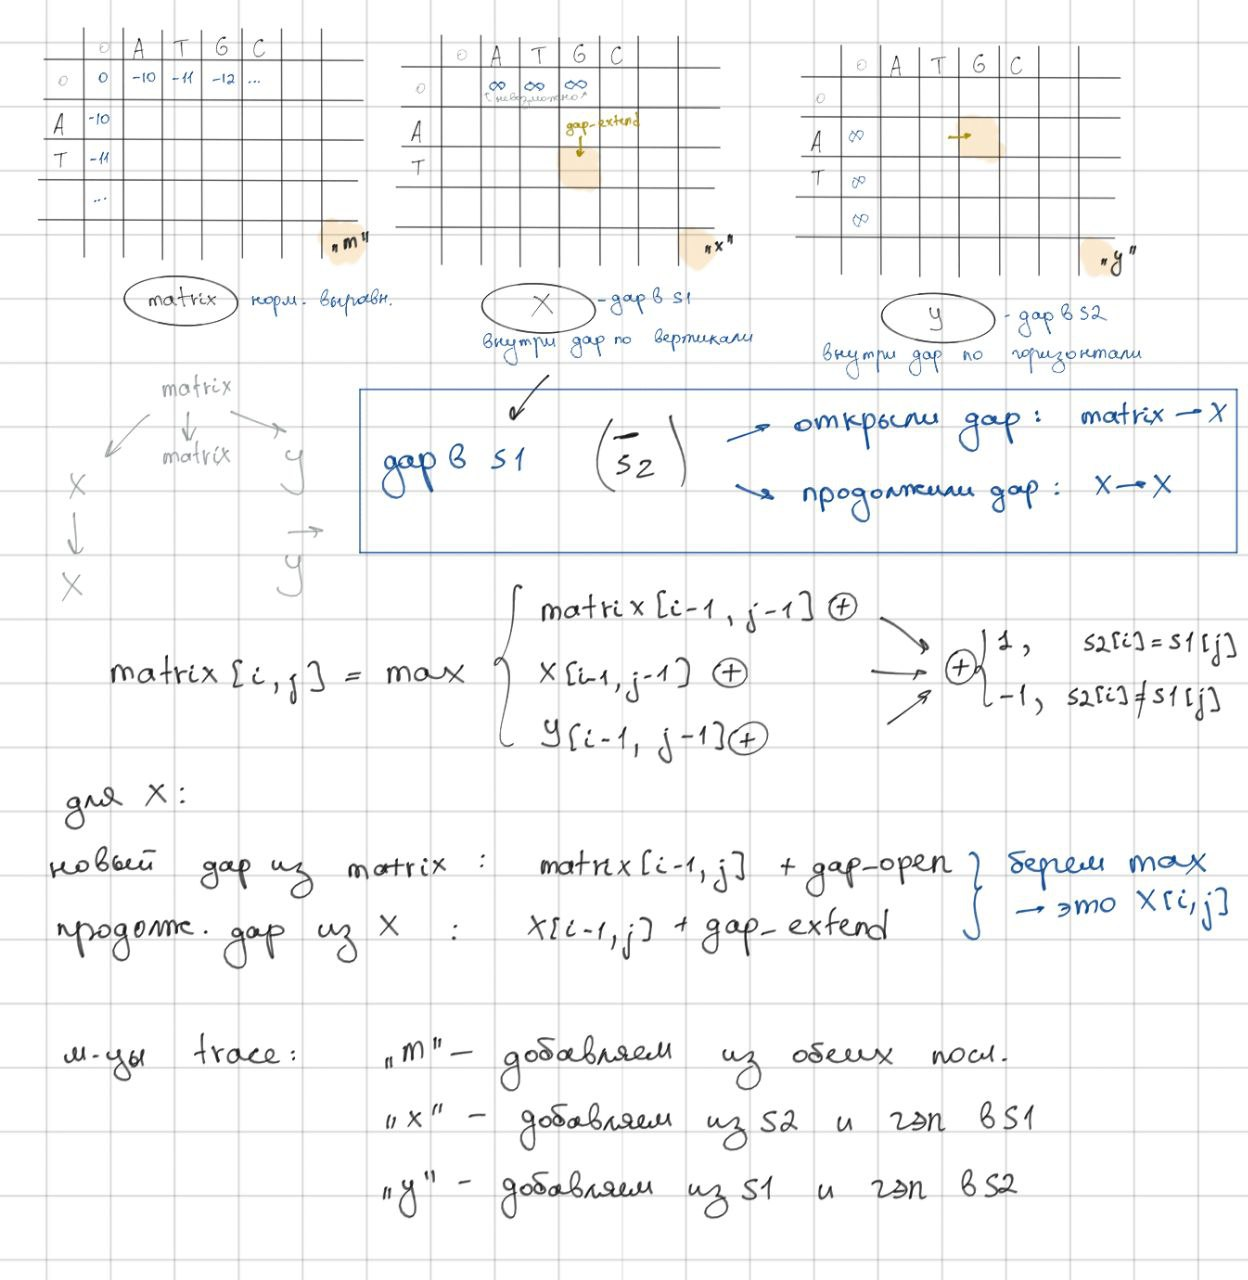

In [20]:
traceM = [["вверх" if i>0 and j==0 else "влево" if j>0 and i==0 else "" for j in range(len(s1)+1)] for i in range(len(s2)+1)]

traceX = [["" for j in range(len(s1)+1)] for i in range(len(s2)+1)]
traceY = [["" for j in range(len(s1)+1)] for i in range(len(s2)+1)]

In [21]:
for i in range(1, len(s2)+1):
    for j in range(1, len(s1)+1):

        score = match if s1[j-1] == s2[i-1] else mismatch

        diagM = matrix[i-1][j-1] + score
        diagX = X[i-1][j-1] + score
        diagY = Y[i-1][j-1] + score

        best = max(diagM, diagX, diagY)
        matrix[i][j] = best

        if best == diagM:
            traceM[i][j] = "m"
        elif best == diagX:
            traceM[i][j] = "x"
        else:
            traceM[i][j] = "y"

        open_gap = matrix[i-1][j] + gap_open
        extend_gap = X[i-1][j] + gap_extend

        X[i][j] = max(open_gap, extend_gap)

        if X[i][j] == open_gap:
            traceX[i][j] = "m"
        else:
            traceX[i][j] = "x"

        open_gap = matrix[i][j-1] + gap_open
        extend_gap = Y[i][j-1] + gap_extend

        Y[i][j] = max(open_gap, extend_gap)

        if Y[i][j] == open_gap:
            traceY[i][j] = "m"
        else:
            traceY[i][j] = "y"

In [22]:
i = len(s2)
j = len(s1)

state = max([(matrix[i][j], "m"), (X[i][j], "x"), (Y[i][j], "y")])[1]

In [23]:
al1 = ""
al2 = ""

while i>0 or j>0:

    if state == "m":
        prev = traceM[i][j]
        al1 = s1[j-1] + al1
        al2 = s2[i-1] + al2
        i -= 1
        j -= 1
        state = prev

    elif state == "x":
        prev = traceX[i][j]
        al1 = "-" + al1
        al2 = s2[i-1] + al2
        i -= 1
        state = prev

    else:
        prev = traceY[i][j]
        al1 = s1[j-1] + al1
        al2 = "-" + al2
        j -= 1
        state = prev

In [25]:
print('Выравнивание:')
print(al1)
print(al2)

Выравнивание:
ATGCAGCAGCAGCCA
ATATAT---------


In [45]:
score = max(matrix[len(s2)][len(s1)], X[len(s2)][len(s1)], Y[len(s2)][len(s1)])
print("Score:", score)
print('Матрица:')
print_matrix_pandas(matrix)

Score: -18
Матрица:
        A   T   G   C   A   G   C   A   G   C   A   G   C   C   A
    0 -10 -11 -12 -13 -14 -15 -16 -17 -18 -19 -20 -21 -22 -23 -24
A -10   1 -11 -12 -13 -12 -15 -16 -15 -18 -19 -18 -21 -22 -23 -22
T -11 -11   2 -10 -11 -12 -13 -14 -15 -16 -17 -18 -19 -20 -21 -22
A -12 -10 -10   1  -9  -8 -11 -12 -11 -14 -15 -14 -17 -18 -19 -18
T -13 -13  -9  -9   0 -10  -9 -12 -13 -12 -15 -16 -15 -18 -19 -20
A -14 -12 -12 -10 -10   1 -11 -10 -11 -14 -13 -14 -17 -16 -19 -18
T -15 -15 -11 -11 -11 -11   0 -10 -11 -12 -13 -14 -15 -16 -17 -18


## Вывод

С линейным штрафом каждый гэп кусок считается одинаково плохо, поэтому алгоритм ставит много коротких дырок.
С аффинным штрафом открывать гэп дорого, а продолжать почти бесплатно, поэтому алгоритм делает один длинный гэп вместо кучи маленьких. То есть аффинная модель делает выравнивание более естественным: одна инсерция или делеция — это одно событие.